In [23]:
import nflreadpy as nfl
import pandas as pd
import matplotlib.pyplot as plt

ff_opp = nfl.load_ff_opportunity(
    seasons=range(2018, 2026)
).to_pandas()

ff_opp.head()

,season,posteam,week,game_id,player_id,full_name,position,pass_attempt,rec_attempt,rush_attempt,...,total_yards_gained_diff_team,total_touchdown_team,total_touchdown_exp_team,total_touchdown_diff_team,total_first_down_team,total_first_down_exp_team,total_first_down_diff_team,total_fantasy_points_team,total_fantasy_points_exp_team,total_fantasy_points_diff_team
0,2018,ATL,1.0,2018_01_ATL_PHI,00-0026143,Matt Ryan,QB,43.0,0.0,2.0,...,-56.65,1.0,4.87,-3.87,14.0,19.53,-5.53,59.5,94.01,-34.51
1,2018,ATL,1.0,2018_01_ATL_PHI,00-0027944,Julio Jones,WR,0.0,19.0,1.0,...,-56.65,1.0,4.87,-3.87,14.0,19.53,-5.53,59.5,94.01,-34.51
2,2018,ATL,1.0,2018_01_ATL_PHI,00-0034837,Calvin Ridley,WR,0.0,2.0,0.0,...,-56.65,1.0,4.87,-3.87,14.0,19.53,-5.53,59.5,94.01,-34.51
3,2018,ATL,1.0,2018_01_ATL_PHI,00-0031285,Devonta Freeman,RB,0.0,5.0,6.0,...,-56.65,1.0,4.87,-3.87,14.0,19.53,-5.53,59.5,94.01,-34.51
4,2018,PHI,1.0,2018_01_ATL_PHI,00-0029567,Nick Foles,QB,34.0,1.0,1.0,...,-123.93,2.0,1.77,0.23,14.0,20.90,-6.90,58.5,71.96,-13.46


In [24]:
ff_opp["season"].unique()
ff_opp["season"] = pd.to_numeric(ff_opp["season"], errors="coerce")

In [25]:
current = ff_opp[ff_opp["season"] == 2025]

player_rankings = (
    current
    .groupby(["player_id", "full_name", "position"])
    ["total_fantasy_points_exp"]
    .mean()
    .reset_index()
    .sort_values("total_fantasy_points_exp", ascending=False)
)

player_rankings.head(20)

,player_id,full_name,position,total_fantasy_points_exp
49,00-0033280,Christian McCaffrey,RB,24.782632
252,00-0036971,Trevor Lawrence,QB,21.439444
75,00-0033873,Patrick Mahomes,QB,21.282143
117,00-0034857,Josh Allen,QB,20.882222
41,00-0033077,Dak Prescott,QB,20.869412
4,00-0026498,Matthew Stafford,QB,20.702000
425,00-0039075,Puka Nacua,WR,20.146316
505,00-0039918,Caleb Williams,QB,20.023158
327,00-0037834,Brock Purdy,QB,19.465455
472,00-0039732,Bo Nix,QB,19.352778


In [26]:
print("Rows:", len(ff_opp))
print("Players:", ff_opp["player_id"].nunique())
print("Games:", ff_opp["game_id"].nunique())

print(ff_opp["position"].value_counts())

Rows: 47282
Players: 1639
Games: 2227
position
WR      17640
RB      11852
TE       8828
QB       5385
SPEC      105
DB        102
OL         73
P          35
LB         24
DL         12
K           1
Name: count, dtype: int64


In [27]:
df = ff_opp[
    ff_opp["position"].isin(["QB", "RB", "WR", "TE"])
].copy()

df.columns.to_list()

['season',
 'posteam',
 'week',
 'game_id',
 'player_id',
 'full_name',
 'position',
 'pass_attempt',
 'rec_attempt',
 'rush_attempt',
 'pass_air_yards',
 'rec_air_yards',
 'pass_completions',
 'receptions',
 'pass_completions_exp',
 'receptions_exp',
 'pass_yards_gained',
 'rec_yards_gained',
 'rush_yards_gained',
 'pass_yards_gained_exp',
 'rec_yards_gained_exp',
 'rush_yards_gained_exp',
 'pass_touchdown',
 'rec_touchdown',
 'rush_touchdown',
 'pass_touchdown_exp',
 'rec_touchdown_exp',
 'rush_touchdown_exp',
 'pass_two_point_conv',
 'rec_two_point_conv',
 'rush_two_point_conv',
 'pass_two_point_conv_exp',
 'rec_two_point_conv_exp',
 'rush_two_point_conv_exp',
 'pass_first_down',
 'rec_first_down',
 'rush_first_down',
 'pass_first_down_exp',
 'rec_first_down_exp',
 'rush_first_down_exp',
 'pass_interception',
 'rec_interception',
 'pass_interception_exp',
 'rec_interception_exp',
 'rec_fumble_lost',
 'rush_fumble_lost',
 'pass_fantasy_points_exp',
 'rec_fantasy_points_exp',
 'rush_f

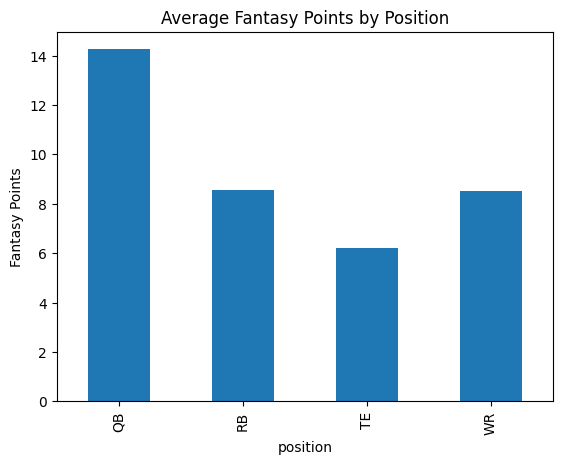

In [28]:
df.groupby("position")["total_fantasy_points"].mean().plot(
    kind="bar",
    title="Average Fantasy Points by Position"
)

plt.ylabel("Fantasy Points")
plt.show()

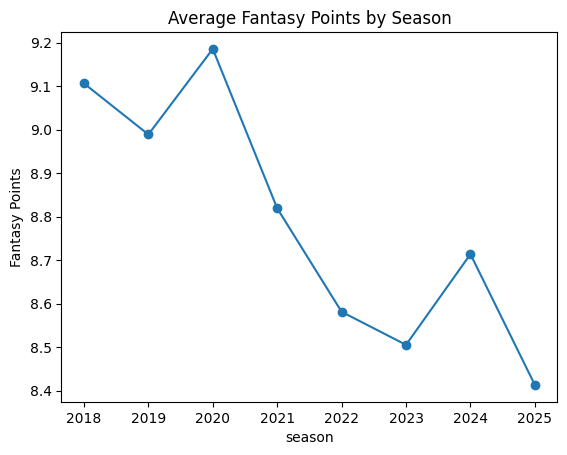

In [29]:
df.groupby("season")["total_fantasy_points"].mean().plot(
    marker="o",
    title="Average Fantasy Points by Season"
)

plt.ylabel("Fantasy Points")
plt.show()

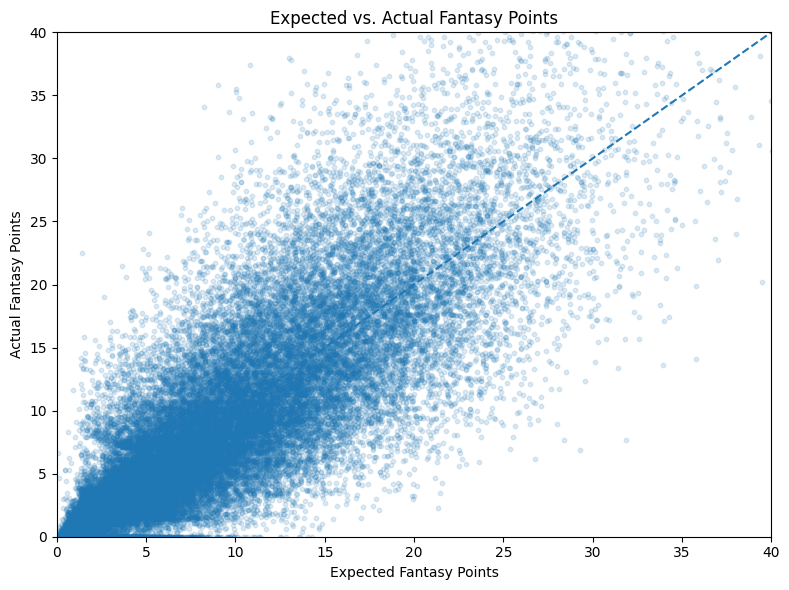

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["total_fantasy_points_exp"],
    df["total_fantasy_points"],
    alpha=0.15,
    s=10
)

max_value = 40

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Expected Fantasy Points")
plt.ylabel("Actual Fantasy Points")
plt.title("Expected vs. Actual Fantasy Points")

plt.xlim(0, max_value)
plt.ylim(0, max_value)

plt.tight_layout()
plt.show()

In [31]:
df[
    [
        "full_name",
        "position",
        "rec_attempt",
        "rush_attempt",
        "total_yards_gained",
        "total_touchdown",
        "total_fantasy_points"
    ]
].head(20)

,full_name,position,rec_attempt,rush_attempt,total_yards_gained,total_touchdown,total_fantasy_points
0,Matt Ryan,QB,0.0,2.0,259.0,0.0,8.84
1,Julio Jones,WR,19.0,1.0,180.0,0.0,28.00
2,Calvin Ridley,WR,2.0,0.0,0.0,0.0,0.00
3,Devonta Freeman,RB,5.0,6.0,50.0,0.0,8.00
4,Nick Foles,QB,1.0,1.0,131.0,0.0,5.08
5,Nelson Agholor,WR,10.0,1.0,64.0,0.0,13.50
6,Darren Sproles,RB,7.0,5.0,32.0,0.0,7.20
7,Mohamed Sanu,WR,6.0,0.0,18.0,0.0,5.80
8,Tevin Coleman,RB,2.0,9.0,45.0,1.0,11.50
9,Austin Hooper,TE,4.0,0.0,24.0,0.0,5.40
